In [7]:
import pandas as pd
df=pd.read_csv(r"D:\项目\cookie_cats.csv")# ← 改成你本地的路径
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [2]:
print(df.shape) #总用户数
print(df.isnull().sum())#空值
print(df.duplicated().sum())#重复值
print(df['version'].value_counts())#两组人数是否接近

(90189, 5)
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64
0
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64


异常值检查

In [8]:
print(df['sum_gamerounds'].describe())
print(df['sum_gamerounds'].max())#异常值处理

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64
49854


处理异常值

In [9]:
print(df['sum_gamerounds'].sort_values(ascending=False).head(10))#查看异常值
df = df[df['sum_gamerounds'] < 49854]

57702    49854
7912      2961
29417     2640
43671     2438
48188     2294
46344     2251
87007     2156
36933     2124
88328     2063
6536      2015
Name: sum_gamerounds, dtype: int64


验证随机分组

In [10]:
print(df.groupby('version')['sum_gamerounds'].mean())#分组检验
print(df.groupby('version')['sum_gamerounds'].median())

version
gate_30    51.342111
gate_40    51.298776
Name: sum_gamerounds, dtype: float64
version
gate_30    17.0
gate_40    16.0
Name: sum_gamerounds, dtype: float64


留存率计算

In [13]:
retention1_rate = df.groupby('version')['retention_1'].mean()
retention7_rate = df.groupby('version')['retention_7'].mean()
print(f"一日留存率\n",retention1_rate)
print(f"七日留存率\n",retention7_rate)

一日留存率
 version
gate_30    0.448198
gate_40    0.442283
Name: retention_1, dtype: float64
七日留存率
 version
gate_30    0.190183
gate_40    0.182000
Name: retention_7, dtype: float64


可视化

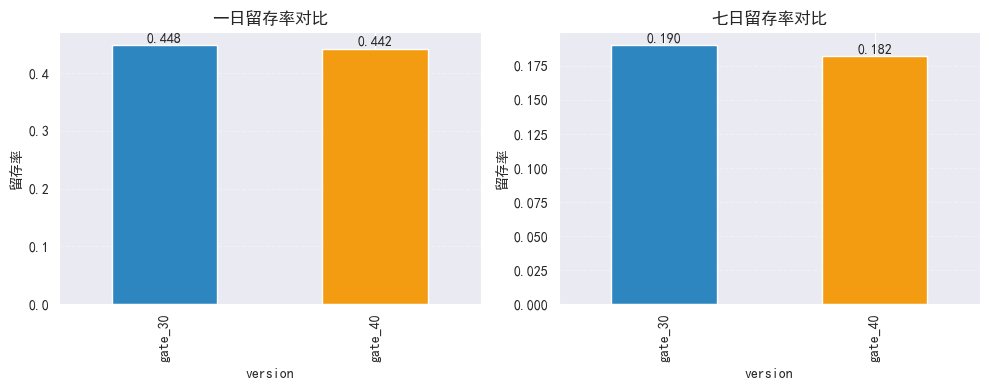

In [16]:
import matplotlib.pyplot as plt
from matplotlib import rcParams  #字体
rcParams['font.sans-serif'] = ['SimHei']
rcParams['font.family'] = ['SimHei']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

retention1_rate.plot(kind='bar', ax=axes[0], color=['#2E86C1', '#F39C12'])
axes[0].set_title('一日留存率对比')
axes[0].set_ylabel('留存率')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(retention1_rate):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

retention7_rate.plot(kind='bar', ax=axes[1], color=['#2E86C1', '#F39C12'])
axes[1].set_title('七日留存率对比')
axes[1].set_ylabel('留存率')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(retention7_rate):
    axes[1].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

卡方检验

In [15]:
from scipy.stats import chi2_contingency

# 构建交叉表——一日留存
contingency_1 = pd.crosstab(df['version'], df['retention_1'])
print(contingency_1)

chi2_1, p_1, dof_1, expected_1 = chi2_contingency(contingency_1)
print(f"\n一日留存 卡方检验：")
print(f"chi2 = {chi2_1:.4f}, p值 = {p_1:.4f}")

# 构建交叉表——七日留存
contingency_7 = pd.crosstab(df['version'], df['retention_7'])
print(contingency_7)

chi2_7, p_7, dof_7, expected_7 = chi2_contingency(contingency_7)
print(f"\n七日留存 卡方检验：")
print(f"chi2 = {chi2_7:.4f}, p值 = {p_7:.4f}")

retention_1  False  True 
version                  
gate_30      24665  20034
gate_40      25370  20119

一日留存 卡方检验：
chi2 = 3.1698, p值 = 0.0750
retention_7  False  True 
version                  
gate_30      36198   8501
gate_40      37210   8279

七日留存 卡方检验：
chi2 = 9.9153, p值 = 0.0016


## 卡方检验结果解读

### 一日留存（retention_1）
- chi2 = 3.1698，**p值 = 0.0750**
- p > 0.05，差异**不显著**
- 结论：gate_30和gate_40在次日留存率上的差异（44.8% vs 44.2%），
  **无法排除随机波动的可能**，不能认为两个版本有本质区别

### 七日留存（retention_7）
- chi2 = 9.9153，**p值 = 0.0016**
- p < 0.05，差异**显著**
- 结论：gate_30和gate_40在7日留存率上的差异（19.0% vs 18.2%），
  **是真实存在的差异，不是随机波动**

### 核心发现
两个指标给出了不同的信号——
短期（1日）来看两个版本没有显著差别，
但长期（7日）来看，gate_30明显优于gate_40。

这说明把关卡门槛从第30关移到第40关，
**对用户短期体验影响不大，但会显著损害长期留存。**

差异量化

In [18]:
import numpy as np

def cohen_h(p1, p2):
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))

# 一日留存
p1_r1 = retention1_rate['gate_30']
p2_r1 = retention1_rate['gate_40']
h1 = cohen_h(p1_r1, p2_r1)

# 七日留存
p1_r7 = retention7_rate['gate_30']
p2_r7 = retention7_rate['gate_40']
h7 = cohen_h(p1_r7, p2_r7)

print(f"一日留存 Cohen's h = {h1:.4f}")
print(f"七日留存 Cohen's h = {h7:.4f}")

一日留存 Cohen's h = 0.0119
七日留存 Cohen's h = 0.0210


## 一、核心结论
 
- 将游戏关卡门槛从第30关后移至第40关（gate_40方案），对用户次日留存无显著负面影响，但会显著降低用户7日长期留存；整体差异幅度偏小，属于小幅的长期留存损耗。
 
## 二、分指标详细说明
 
- 1.短期表现：1日留存无统计显著差异
gate_30 次日留存44.8%，gate_40 次日留存44.2%，卡方检验 p=0.075＞0.05，未达到95%置信度下的显著标准。
业务含义：用户首日游戏进度尚未触达关卡门槛位置，门槛后移对首日体验与留存没有可验证的实质影响，观测到的微弱差距属于正常用户随机波动。
- 2.长期表现：7日留存显著小幅下降
gate_30 7日留存19.0%，gate_40 7日留存18.2%，卡方检验 p=0.0016＜0.05，差异具备高度统计显著性，可认定为方案改动带来的真实影响。
从差异幅度看，7日留存绝对下降0.8个百分点，相对下降约4.2%；Cohen's h 效应量为0.021，属于极小效应——说明差异统计上高度可信，但实际业务影响幅度有限，不属于剧烈的留存滑坡。
 
## 三、业务判断与建议
 
- 1.改动影响存在滞后性：短期次日指标无法完整反映关卡调整的真实效果，需以7日及更长期留存作为核心决策依据。
- 2.方案取舍建议：若本次调整无其他配套正向收益（如付费提升、广告eCPM提升），仅从留存维度不建议全量上线 gate_40 方案；若改动伴随其他业务收益，可综合评估收益与小幅留存损耗的性价比。
- 3.优化方向：可进一步分析用户闯关进度分布、关卡流失节点，定位40关门槛导致长期留存下滑的具体原因，针对性优化关卡难度曲线。

In [19]:
from scipy.stats import levene, ttest_ind

# 先分组
gate_30 = df[df['version'] == 'gate_30']['sum_gamerounds']
gate_40 = df[df['version'] == 'gate_40']['sum_gamerounds']

# 第一步：Levene检验方差齐性
stat, p_levene = levene(gate_30, gate_40)
print(f"Levene检验：stat = {stat:.4f}, p = {p_levene:.4f}")

# 第二步：根据Levene结果选择t检验
# equal_var=True → 标准t检验，equal_var=False → Welch's t检验
if p_levene < 0.05:
    print("方差不齐，使用Welch's t检验")
    t_stat, p_t = ttest_ind(gate_30, gate_40, equal_var=False)
else:
    print("方差齐性，使用标准t检验")
    t_stat, p_t = ttest_ind(gate_30, gate_40, equal_var=True)

print(f"t检验：t = {t_stat:.4f}, p = {p_t:.4f}")

# 第三步：Cohen's d效应量
pooled_std = np.sqrt((gate_30.std()**2 + gate_40.std()**2) / 2)
cohens_d = (gate_30.mean() - gate_40.mean()) / pooled_std
print(f"Cohen's d = {cohens_d:.4f}")

Levene检验：stat = 0.0751, p = 0.7840
方差齐性，使用标准t检验
t检验：t = 0.0634, p = 0.9495
Cohen's d = 0.0004


### 游戏轮数 t检验补充分析

- Levene检验：p = 0.7840 > 0.05，方差齐性，采用标准t检验
- t检验：t = 0.0634，p = 0.9495 > 0.05，**两组游戏轮数无显著差异**
- Cohen's d = 0.0004，效应量趋近于0

**结论**：gate_30和gate_40两组用户在游戏活跃度（sum_gamerounds）上表现一致，
说明关卡门槛位置的调整**未对用户的游戏参与深度产生影响**，
差异仅体现在7日长期留存这一个维度上，且该差异效应量极小。